In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
two_blobs = pd.read_csv('./data/cluster_two_blobs.csv')
two_blobs_outliers = pd.read_csv('./data/cluster_two_blobs_outliers.csv')

<Axes: xlabel='X1', ylabel='X2'>

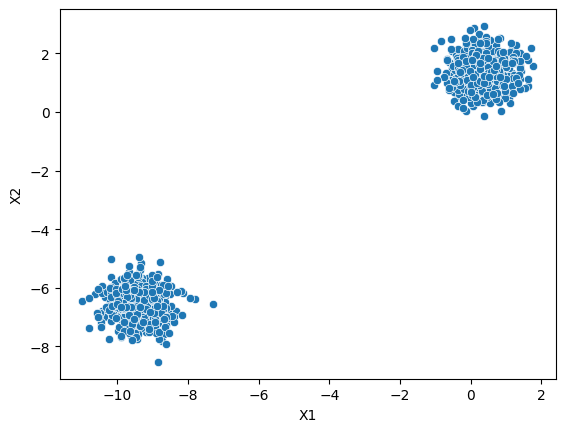

In [3]:
sns.scatterplot(data=two_blobs,x='X1',y='X2')

<Axes: xlabel='X1', ylabel='X2'>

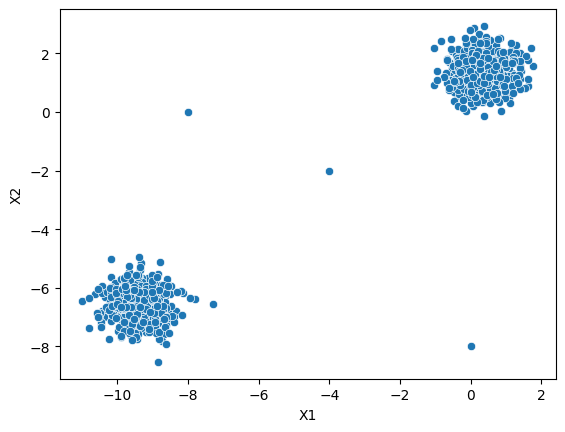

In [4]:
# plt.figure(figsize=(10,6),dpi=200)
sns.scatterplot(data=two_blobs_outliers,x='X1',y='X2')

In [5]:
def display_categories(model,data):
    labels = model.fit_predict(data)
    sns.scatterplot(data=data,x='X1',y='X2',hue=labels,palette='Set1')

In [6]:
from sklearn.cluster import DBSCAN

In [7]:
dbscan = DBSCAN()

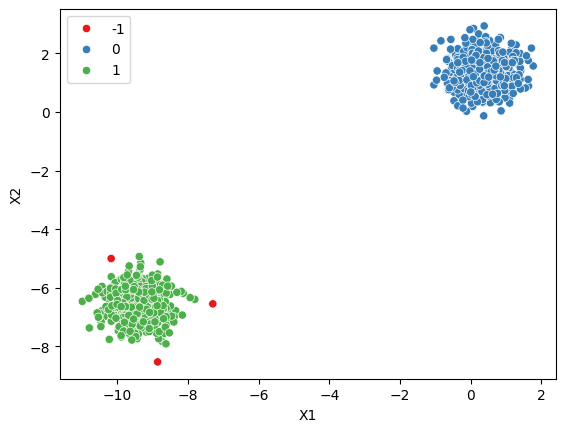

In [8]:
display_categories(dbscan,two_blobs)

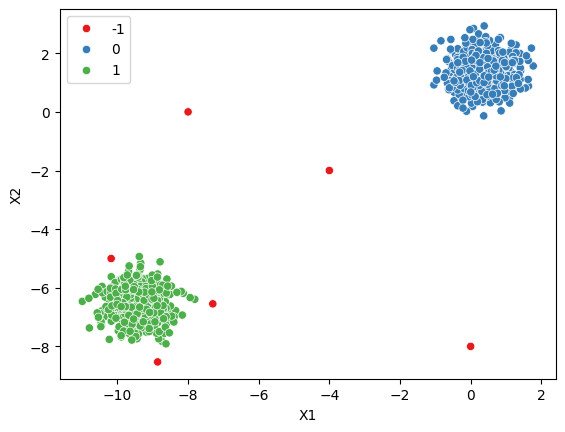

In [9]:
display_categories(dbscan,two_blobs_outliers)

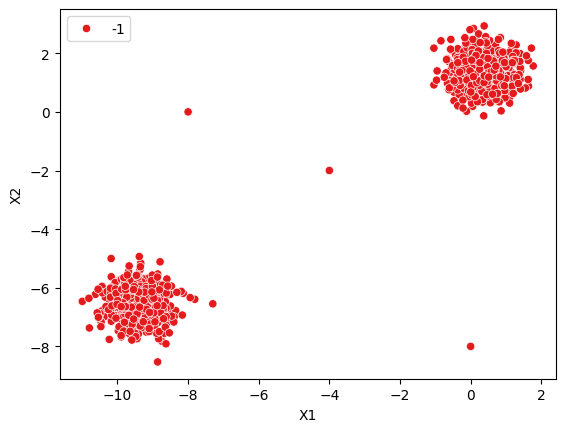

In [10]:
dbscan = DBSCAN(eps=0.001)
display_categories(dbscan,two_blobs_outliers)

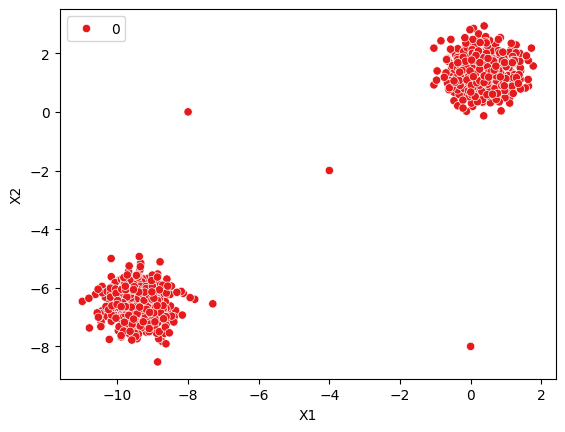

In [11]:
dbscan = DBSCAN(eps=10)
display_categories(dbscan,two_blobs_outliers)

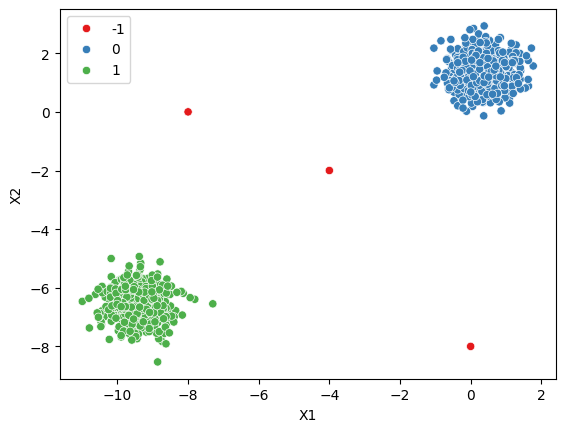

In [12]:
dbscan = DBSCAN(eps=1)
display_categories(dbscan,two_blobs_outliers)

In [13]:
dbscan.labels_

array([ 0,  1,  0, ..., -1, -1, -1], shape=(1003,))

In [16]:
dbscan.labels_ == -1

array([False, False, False, ...,  True,  True,  True], shape=(1003,))

In [17]:
np.sum(dbscan.labels_ == -1)

np.int64(3)

In [18]:
100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)

np.float64(0.29910269192422734)

In [19]:
len(dbscan.labels_)

1003

In [32]:
outlier_percent = []
number_of_outliers = []

for eps in np.linspace(0.001,1,100):
    dbscan = DBSCAN(eps=eps)
    dbscan.fit(two_blobs_outliers)

    # Total Outliers Found
    number_of_outliers.append(np.sum(dbscan.labels_ == -1))

    # Percentage points classified as outliers
    percent_outleers = (100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_))
    outlier_percent.append(percent_outleers)

(0.0, 2.0)

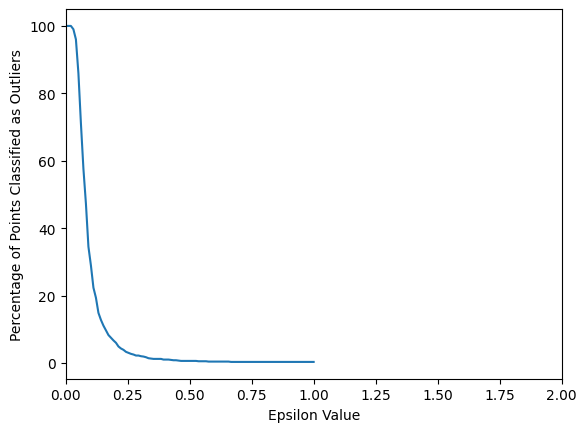

In [33]:
sns.lineplot(x=np.linspace(0.001,1,100),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")
plt.xlim(0,2)

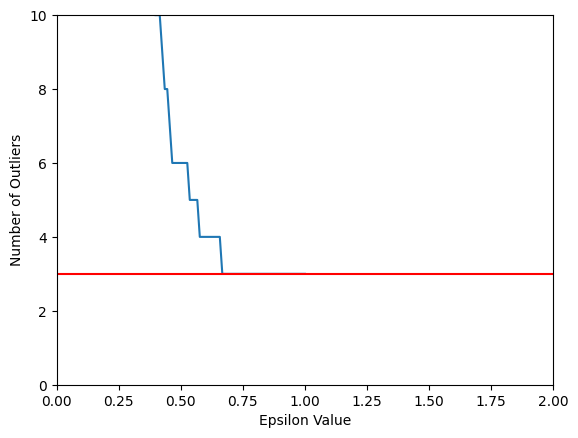

In [ ]:
sns.lineplot(x=np.linspace(0.001,1,100),y=number_of_outliers)
plt.ylabel("Number of Outliers")
plt.xlabel("Epsilon Value")
plt.xlim(0,2)
plt.ylim(0,10)
plt.hlines(y=3,xmin=0, xmax=2, color='red')

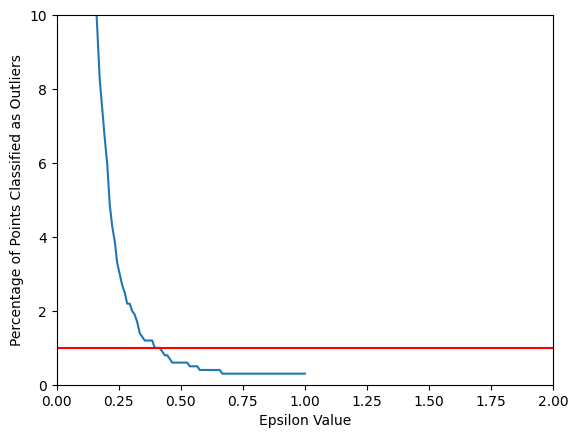

In [ ]:
sns.lineplot(x=np.linspace(0.001,1,100),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")
plt.xlim(0,2)
plt.ylim(0,10)
plt.hlines(y=1,xmin=0, xmax=2, color='red')

In [37]:
outlier_percent = []
number_of_outliers = []

for n in np.arange(1,100):
    dbscan = DBSCAN(min_samples=n)
    dbscan.fit(two_blobs_outliers)

    # Total Outliers Found
    number_of_outliers.append(np.sum(dbscan.labels_ == -1))

    # Percentage points classified as outliers
    percent_outleers = (100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_))
    outlier_percent.append(percent_outleers)

Text(0.5, 0, 'Minimum Number of Samples')

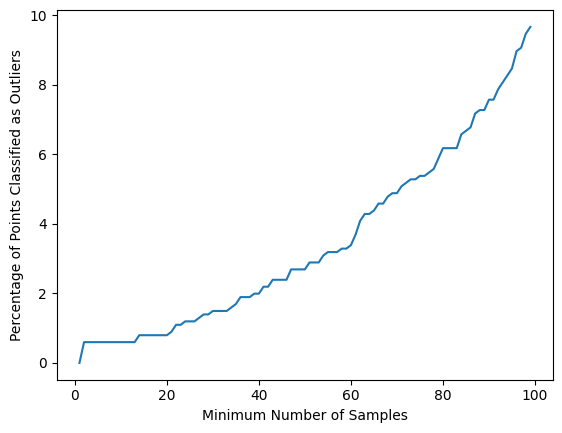

In [38]:
sns.lineplot(x=np.arange(1,100),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Minimum Number of Samples")

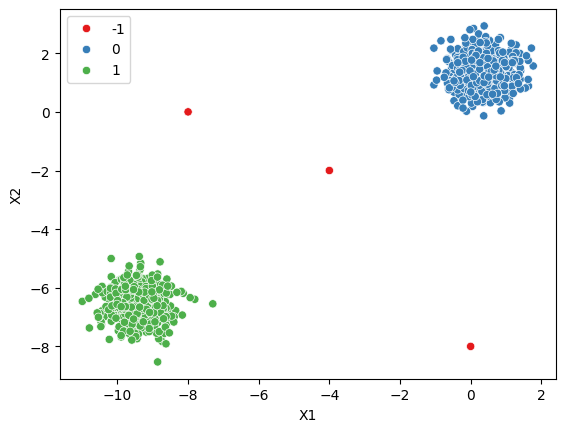

In [39]:
num_dim = two_blobs_outliers.shape[1]

dbscan = DBSCAN(min_samples=2*num_dim, eps=0.75)
display_categories(dbscan,two_blobs_outliers)